In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df=pd.read_csv('car.data',header=None)
df

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [23]:
df.shape

(1728, 7)

In [24]:
df.columns=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [25]:
df.info

<bound method DataFrame.info of      buying  maint  doors persons lug_boot safety  class
0     vhigh  vhigh      2       2    small    low  unacc
1     vhigh  vhigh      2       2    small    med  unacc
2     vhigh  vhigh      2       2    small   high  unacc
3     vhigh  vhigh      2       2      med    low  unacc
4     vhigh  vhigh      2       2      med    med  unacc
...     ...    ...    ...     ...      ...    ...    ...
1723    low    low  5more    more      med    med   good
1724    low    low  5more    more      med   high  vgood
1725    low    low  5more    more      big    low  unacc
1726    low    low  5more    more      big    med   good
1727    low    low  5more    more      big   high  vgood

[1728 rows x 7 columns]>

In [26]:
df['class'].value_counts()


class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [27]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [28]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [29]:
x=df.drop(['class'],axis=1)
x.head()

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med


In [30]:
y=df['class']
y.head()

0    unacc
1    unacc
2    unacc
3    unacc
4    unacc
Name: class, dtype: object

In [31]:
#train x,y split test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


In [32]:
x_train.shape,x_test.shape

((1209, 6), (519, 6))

In [33]:
x_train.head()

,buying,maint,doors,persons,lug_boot,safety
1178,med,med,5more,4,big,high
585,high,high,3,more,small,low
1552,low,med,3,4,med,med
1169,med,med,5more,2,big,high
1033,med,high,4,2,big,med


In [38]:
# for encodeing the data set 

import category_encoders as ce
encoder=ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])
x_train=encoder.fit_transform(x_train)
x_test=encoder.transform(x_test)
encoder

,verbose,0
,mapping,"[{'col': 'buying', 'data_type': dtype('int64'), 'mapping': 1.0 1 2.0 ...2 dtype: int64}, {'col': 'maint', 'data_type': dtype('int64'), 'mapping': 1.0 1 2.0 ...2 dtype: int64}, ...]"
,cols,"['buying', 'maint', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'


In [44]:
from sklearn.tree import DecisionTreeClassifier
clf_gini=DecisionTreeClassifier(criterion='gini',max_depth=4,random_state=0)
clf_gini.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


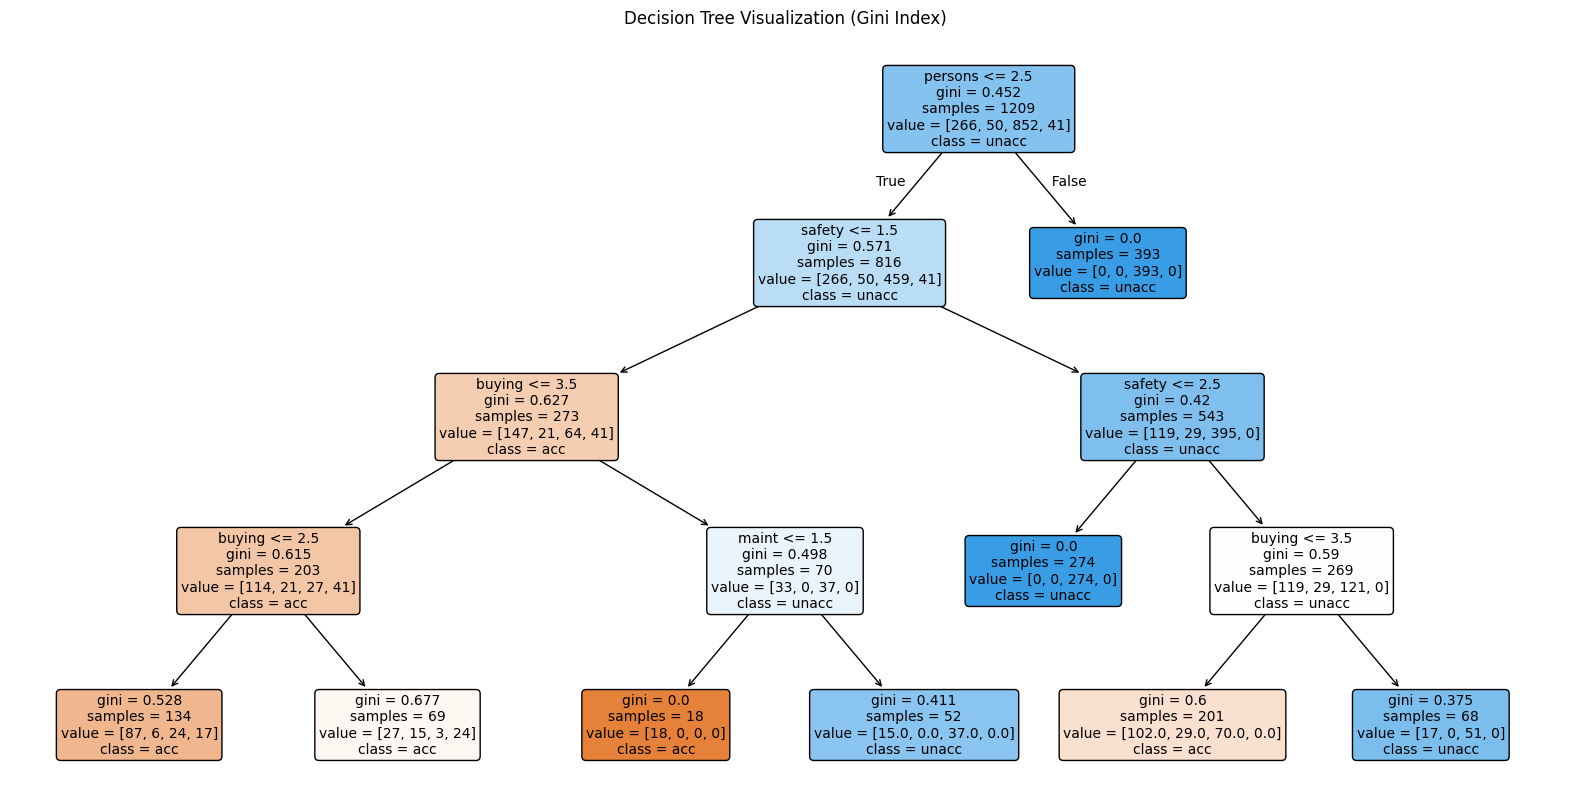

In [45]:
from sklearn import tree
import matplotlib.pyplot as plt

# Visualize the trained decision tree
plt.figure(figsize=(20,10))  # make the plot big and clear

tree.plot_tree(
    clf_gini,
    feature_names=x_train.columns,     # names of the input features
    class_names=[str(c) for c in clf_gini.classes_],  # names of the target classes
    filled=True,        # color the nodes
    rounded=True,       # round the boxes
    fontsize=10
)

plt.title("Decision Tree Visualization (Gini Index)")
plt.show()

In [46]:
y_pred_gini=clf_gini.predict(x_test)


In [55]:
from sklearn.metrics import accuracy_score
#accuracy=accuracy_score(y_test,y_pred_gini)
print("Model accurace score with criterion gini.indiex:{0:0.4f}".format(accuracy_score(y_test,y_pred_gini)))

Model accurace score with criterion gini.indiex:0.8189


In [56]:
y_pred_gini=clf_gini.predict(x_test)


In [60]:
print('Training set score: {:.4f}'.format(clf_gini.score(x_train, y_train)))
print('Test set score: {:.4f}'.format(clf_gini.score(x_test, y_test)))

Training set score: 0.8180
Test set score: 0.8189


In [51]:
clf_en=DecisionTreeClassifier(criterion='entropy',max_depth=3,random_state=0)
clf_en.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None
